<a href="https://colab.research.google.com/github/LCaravaggio/Cosas_Sueltas/blob/main/VIIRS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import os
from google.colab import userdata

import os
from google.colab import userdata

username = "lcaravaggio"
password = userdata.get("NASA")

# Crear .netrc correctamente
netrc_content = f"""machine urs.earthdata.nasa.gov
login {username}
password {password}
"""

with open("/root/.netrc", "w") as f:
    f.write(netrc_content)

os.chmod("/root/.netrc", 0o600)

# Cookie file
!touch ~/.urs_cookies

# Descarga
!wget \
  --load-cookies ~/.urs_cookies \
  --save-cookies ~/.urs_cookies \
  --keep-session-cookies \
  --auth-no-challenge=on \
  --content-disposition \
  "https://data.laadsdaac.earthdatacloud.nasa.gov/prod-lads/VNP46A2/VNP46A2.A2026104.h12v12.002.2026112102916.h5"

--2026-04-22 17:18:15--  https://data.laadsdaac.earthdatacloud.nasa.gov/prod-lads/VNP46A2/VNP46A2.A2026104.h12v12.002.2026112102916.h5
Resolving data.laadsdaac.earthdatacloud.nasa.gov (data.laadsdaac.earthdatacloud.nasa.gov)... 143.204.55.94, 143.204.55.78, 143.204.55.93, ...
Connecting to data.laadsdaac.earthdatacloud.nasa.gov (data.laadsdaac.earthdatacloud.nasa.gov)|143.204.55.94|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://urs.earthdata.nasa.gov/oauth/authorize?client_id=PIR2OBoAXa-jbm8w9WyxPQ&response_type=code&redirect_uri=https://data.laadsdaac.earthdatacloud.nasa.gov/login&state=%2Fprod-lads%2FVNP46A2%2FVNP46A2.A2026104.h12v12.002.2026112102916.h5&app_type=401 [following]
--2026-04-22 17:18:16--  https://urs.earthdata.nasa.gov/oauth/authorize?client_id=PIR2OBoAXa-jbm8w9WyxPQ&response_type=code&redirect_uri=https://data.laadsdaac.earthdatacloud.nasa.gov/login&state=%2Fprod-lads%2FVNP46A2%2FVNP46A2.A2026104.h12v12.002.2026112102916.h5&app_

In [4]:
import os

def clean_filenames(folder="/content"):
    """
    Renombra archivos que contengan '?' eliminando ese carácter
    y todo lo que le sigue en el nombre.
    """
    for filename in os.listdir(folder):
        if "?" in filename:
            new_name = filename.split("?")[0]

            old_path = os.path.join(folder, filename)
            new_path = os.path.join(folder, new_name)

            if not os.path.exists(new_path):
                os.rename(old_path, new_path)
            else:
                print(f"Ya existe, no se renombra: {new_name}")

clean_filenames()

In [29]:
!wget \
  --load-cookies ~/.urs_cookies \
  --save-cookies ~/.urs_cookies \
  --keep-session-cookies \
  --auth-no-challenge=on \
  --content-disposition \
  "https://data.laadsdaac.earthdatacloud.nasa.gov/prod-lads/VNP46A2/VNP46A2.A2025104.h12v12.002.2025112150101.h5"

--2026-04-22 17:54:47--  https://data.laadsdaac.earthdatacloud.nasa.gov/prod-lads/VNP46A2/VNP46A2.A2025104.h12v12.002.2025112150101.h5
Resolving data.laadsdaac.earthdatacloud.nasa.gov (data.laadsdaac.earthdatacloud.nasa.gov)... 18.161.111.57, 18.161.111.124, 18.161.111.85, ...
Connecting to data.laadsdaac.earthdatacloud.nasa.gov (data.laadsdaac.earthdatacloud.nasa.gov)|18.161.111.57|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://d13j1jds5ybppo.cloudfront.net/s3-8d80a21348b33e9c2ee6e0a8ac41d7b1/prod-lads.s3.us-west-2.amazonaws.com/VNP46A2/VNP46A2.A2025104.h12v12.002.2025112150101.h5?A-userid=lcaravaggio&Expires=1776884089&Signature=mW6-qotAOclp~QWbH3BRY4Y93KR83590a4wFeughnSaZ6PI9yKJYZLo54K4rV6252sluzo1EL2vH2XYYVXvKq4sCZxa5L0p6EDbWdt5SqviiO3bg-Qg27DOJgjXVTqGiIpvU8ZT4gd43HPA3hkr56JJPPs4tpCSjRZYgCmI8CJ8ec-7KvKHS21VEDxK1Yiy7RCCF5JBYXVNUiptEbSlpN9ZtnnX7YV6NHlNdXnN0KDYGZrF4cXVrSmoXrPt7jBYllBXnWAoUJE~WlLvG2zwuCBgDsQk0rUlWrkrBKBAt5za3S9o4k8sHJpgi8Kt7b

In [30]:
clean_filenames()

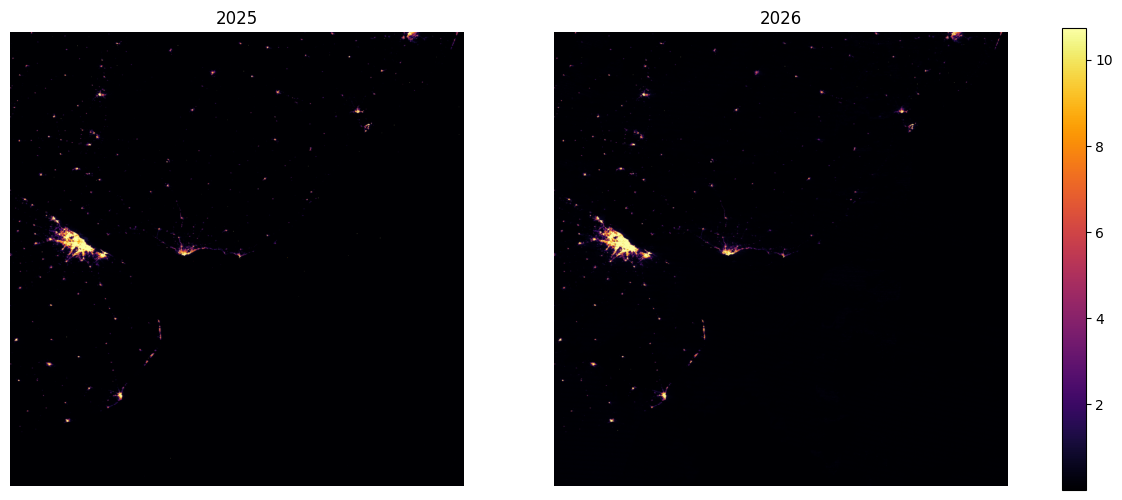

In [31]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

def load_viirs(path):
    with h5py.File(path, "r") as f:
        dset = "HDFEOS/GRIDS/VIIRS_Grid_DNB_2d/Data Fields/"

        data = f[dset + "Gap_Filled_DNB_BRDF-Corrected_NTL"][:]
        qf   = f[dset + "Mandatory_Quality_Flag"][:]

    img = data.astype(float)

    # 1. fill values reales
    #img = np.where(img < 0.1, np.nan, img)

    # 2. filtrar mala calidad (esto sí es seguro)
    #img[qf > 1] = np.nan

    return img


path_2025 = '/content/VNP46A2.A2025104.h12v12.002.2025112150101.h5'
path_2026 = '/content/VNP46A2.A2026104.h12v12.002.2026112102916.h5'

img_2025 = load_viirs(path_2025)
img_2026 = load_viirs(path_2026)




# escala común
stack = np.stack([img_2025, img_2026])
vmin = np.nanpercentile(stack, 5)
vmax = np.nanpercentile(stack, 99.2)

def normalize(img):
    p1, p99 = np.nanpercentile(img, [1, 99])
    return (img - p1) / (p99 - p1)

img_2025 = normalize(img_2025)
img_2026 = normalize(img_2026)

fig, ax = plt.subplots(1, 2, figsize=(14,6))

im0 = ax[0].imshow(img_2025, cmap="inferno", vmin=vmin, vmax=vmax)
ax[0].set_title("2025")

im1 = ax[1].imshow(img_2026, cmap="inferno", vmin=vmin, vmax=vmax)
ax[1].set_title("2026")

for a in ax:
    a.axis("off")

plt.colorbar(im1, ax=ax, fraction=0.03)
plt.show()

In [32]:
gdp_proxy_2025 = np.nansum(img_2025)
gdp_proxy_2026 = np.nansum(img_2026)

growth = (gdp_proxy_2026 - gdp_proxy_2025) / gdp_proxy_2025
print("Crecimiento proxy:", growth)

Crecimiento proxy: 0.3098125573720134
